In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

DATASET_PATH = "/content/drive/MyDrive/BSERC/Final_Dataset"

print("Dataset path:", DATASET_PATH)

Dataset path: /content/drive/MyDrive/BSERC/Final_Dataset


In [ ]:
import os
import cv2
import yaml
import shutil
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
import os
import shutil
import glob

# ============================================================
# Paths
# ============================================================

SOURCE_DATASET = DATASET_PATH

PROCESSED_DATASET = "/content/Processed_Dataset"

# Create output directory
os.makedirs(PROCESSED_DATASET, exist_ok=True)


# ============================================================
# Function: Convert annotations
# ============================================================

def convert_label_file(source_label, output_label):

    converted_annotations = []

    with open(source_label, "r") as f:
        lines = f.readlines()

    for line in lines:

        line = line.strip()

        if not line:
            continue

        values = line.split()

        class_id = values[0]

        coords = list(map(float, values[1:]))

        # ----------------------------------------------------
        # Case 1: Standard YOLO bounding box
        # ----------------------------------------------------

        if len(coords) == 4:

            x_center, y_center, width, height = coords

        # ----------------------------------------------------
        # Case 2: Polygon
        # ----------------------------------------------------

        elif len(coords) >= 6 and len(coords) % 2 == 0:

            x_coordinates = coords[0::2]
            y_coordinates = coords[1::2]

            x_min = min(x_coordinates)
            x_max = max(x_coordinates)

            y_min = min(y_coordinates)
            y_max = max(y_coordinates)

            x_center = (x_min + x_max) / 2
            y_center = (y_min + y_max) / 2

            width = x_max - x_min
            height = y_max - y_min

        else:

            print("WARNING: Invalid annotation:")
            print(source_label)
            print(line)

            continue

        # ----------------------------------------------------
        # Validate coordinates
        # ----------------------------------------------------

        x_center = max(0.0, min(1.0, x_center))
        y_center = max(0.0, min(1.0, y_center))
        width = max(0.0, min(1.0, width))
        height = max(0.0, min(1.0, height))

        converted_annotations.append(
            f"{class_id} "
            f"{x_center:.6f} "
            f"{y_center:.6f} "
            f"{width:.6f} "
            f"{height:.6f}\n"
        )

    # Write converted file

    with open(output_label, "w") as f:
        f.writelines(converted_annotations)


# ============================================================
# Process train / valid / test
# ============================================================

statistics = {}

for split in ["train", "valid", "test"]:

    print("\n" + "=" * 60)
    print(f"PROCESSING {split.upper()}")
    print("=" * 60)

    source_images = os.path.join(
        SOURCE_DATASET,
        split,
        "images"
    )

    source_labels = os.path.join(
        SOURCE_DATASET,
        split,
        "labels"
    )

    output_images = os.path.join(
        PROCESSED_DATASET,
        split,
        "images"
    )

    output_labels = os.path.join(
        PROCESSED_DATASET,
        split,
        "labels"
    )

    os.makedirs(output_images, exist_ok=True)
    os.makedirs(output_labels, exist_ok=True)

    # Copy images

    image_files = glob.glob(
        os.path.join(source_images, "*")
    )

    for image_file in image_files:

        if os.path.isfile(image_file):

            shutil.copy2(
                image_file,
                output_images
            )

    # Convert labels

    label_files = glob.glob(
        os.path.join(source_labels, "*.txt")
    )

    total_boxes = 0
    total_polygons = 0

    for label_file in label_files:

        output_label = os.path.join(
            output_labels,
            os.path.basename(label_file)
        )

        with open(label_file, "r") as f:

            lines = f.readlines()

        for line in lines:

            line = line.strip()

            if not line:
                continue

            coords = line.split()[1:]

            if len(coords) == 4:
                total_boxes += 1

            elif len(coords) >= 6 and len(coords) % 2 == 0:
                total_polygons += 1

        convert_label_file(
            label_file,
            output_label
        )

    statistics[split] = {
        "images": len(image_files),
        "boxes": total_boxes,
        "polygons_converted": total_polygons
    }

    print(f"Images copied       : {len(image_files)}")
    print(f"Bounding boxes      : {total_boxes}")
    print(f"Polygons converted  : {total_polygons}")


print("\n" + "=" * 60)
print("PREPROCESSING COMPLETED")
print("=" * 60)


PROCESSING TRAIN
Images copied       : 3727
Bounding boxes      : 3604
Polygons converted  : 685

PROCESSING VALID
Images copied       : 702
Bounding boxes      : 630
Polygons converted  : 200

PROCESSING TEST
Images copied       : 355
Bounding boxes      : 299
Polygons converted  : 97

PREPROCESSING COMPLETED


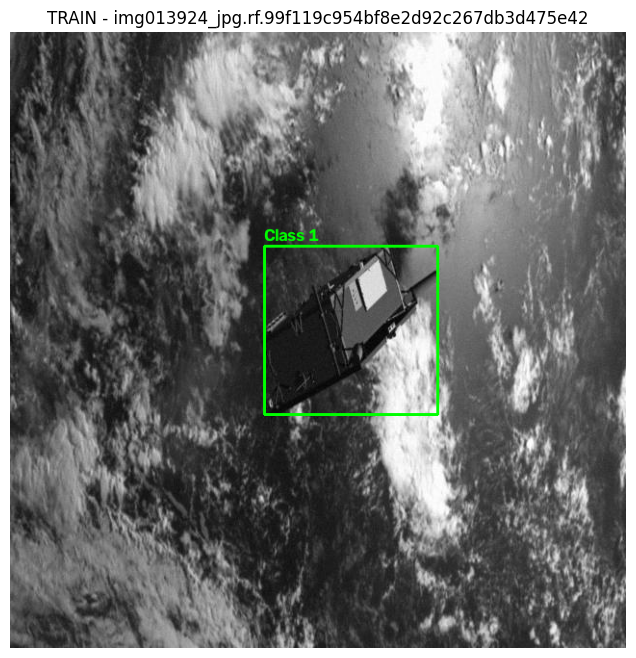

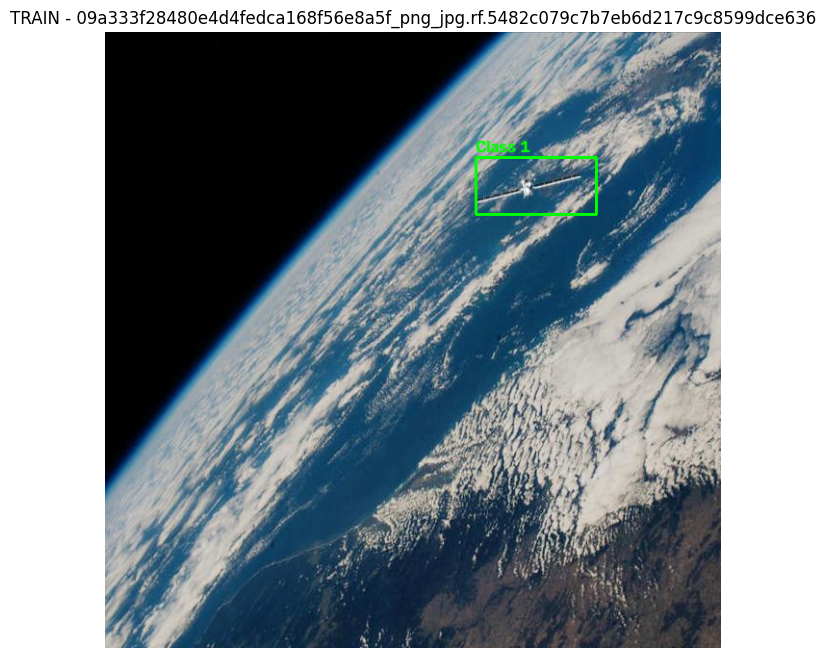

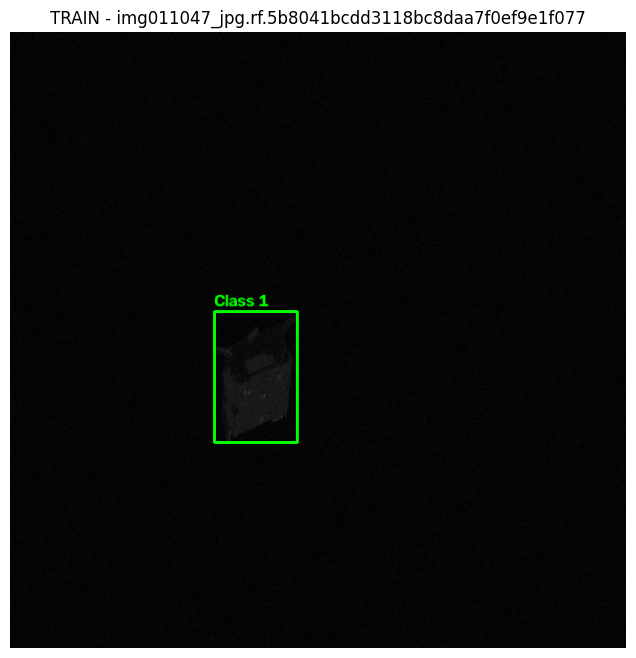

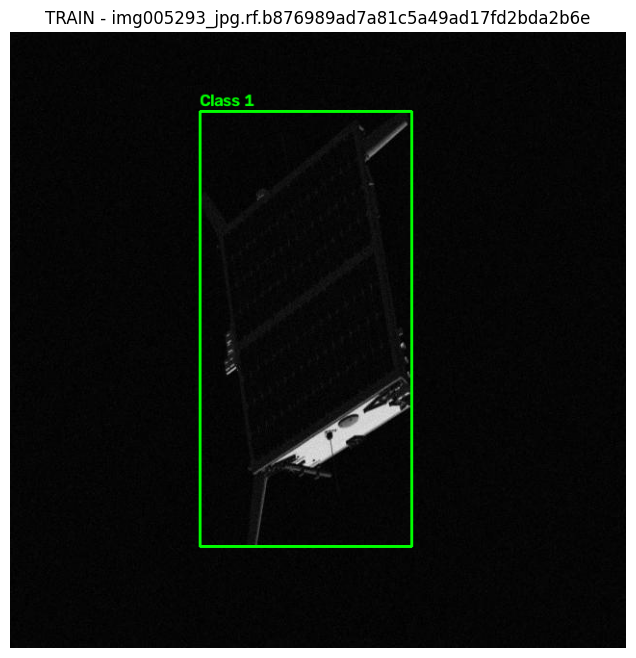

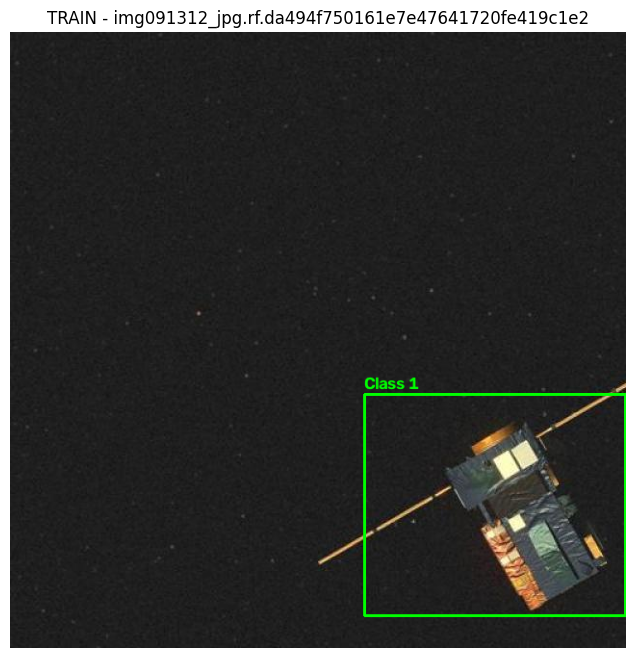

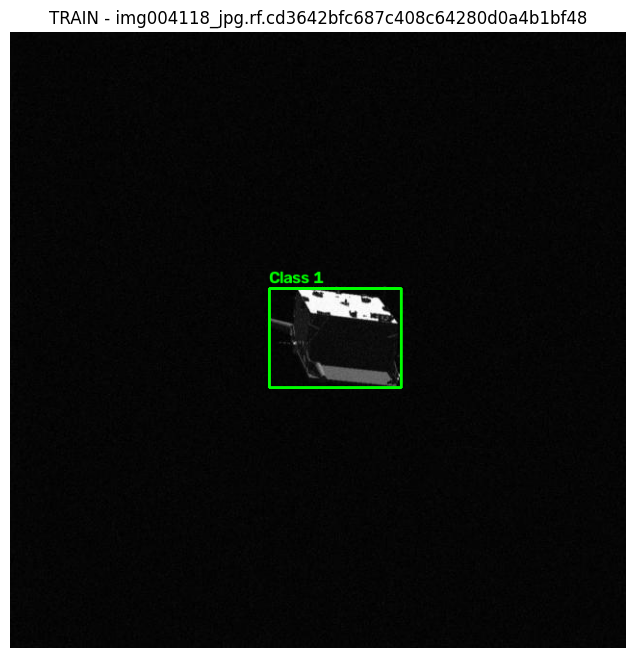

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show_processed_samples(split="train", num_samples=6):

    image_dir = os.path.join(
        PROCESSED_DATASET,
        split,
        "images"
    )

    label_dir = os.path.join(
        PROCESSED_DATASET,
        split,
        "labels"
    )

    image_files = [
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    samples = random.sample(
        image_files,
        min(num_samples, len(image_files))
    )

    for image_path in samples:

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        h, w = image.shape[:2]

        filename = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        label_path = os.path.join(
            label_dir,
            filename + ".txt"
        )

        if os.path.exists(label_path):

            with open(label_path, "r") as f:

                for line in f:

                    values = line.strip().split()

                    if len(values) != 5:
                        continue

                    class_id = int(float(values[0]))

                    x_center = float(values[1])
                    y_center = float(values[2])
                    box_width = float(values[3])
                    box_height = float(values[4])

                    # Convert normalized coordinates
                    # to pixel coordinates

                    x1 = int(
                        (x_center - box_width / 2) * w
                    )

                    y1 = int(
                        (y_center - box_height / 2) * h
                    )

                    x2 = int(
                        (x_center + box_width / 2) * w
                    )

                    y2 = int(
                        (y_center + box_height / 2) * h
                    )

                    # Keep boxes inside image
                    x1 = max(0, min(x1, w - 1))
                    y1 = max(0, min(y1, h - 1))
                    x2 = max(0, min(x2, w - 1))
                    y2 = max(0, min(y2, h - 1))

                    # Draw bounding box
                    cv2.rectangle(
                        image,
                        (x1, y1),
                        (x2, y2),
                        (0, 255, 0),
                        2
                    )

                    # Class label
                    cv2.putText(
                        image,
                        f"Class {class_id}",
                        (x1, max(y1 - 5, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.6,
                        (0, 255, 0),
                        2
                    )

        plt.figure(figsize=(10, 8))
        plt.imshow(image)
        plt.title(
            f"{split.upper()} - {filename}"
        )
        plt.axis("off")
        plt.show()


show_processed_samples("train", 6)

In [ ]:
import os
import glob
import numpy as np


def check_bbox_quality(split):

    label_dir = os.path.join(
        PROCESSED_DATASET,
        split,
        "labels"
    )

    total = 0
    invalid = 0
    very_small = 0
    very_large = 0

    for label_file in glob.glob(
        os.path.join(label_dir, "*.txt")
    ):

        with open(label_file, "r") as f:

            for line in f:

                values = line.strip().split()

                if len(values) != 5:
                    continue

                _, x, y, width, height = map(
                    float,
                    values
                )

                total += 1

                # Coordinates must be normalized
                if not (
                    0 <= x <= 1 and
                    0 <= y <= 1 and
                    0 < width <= 1 and
                    0 < height <= 1
                ):
                    invalid += 1

                area = width * height

                if area < 0.00001:
                    very_small += 1

                if area > 0.80:
                    very_large += 1

    return (
        total,
        invalid,
        very_small,
        very_large
    )


for split in ["train", "valid", "test"]:

    result = check_bbox_quality(split)

    print("\n" + "=" * 50)
    print(split.upper())
    print("=" * 50)

    print("Total boxes       :", result[0])
    print("Invalid boxes     :", result[1])
    print("Very small boxes  :", result[2])
    print("Very large boxes  :", result[3])


TRAIN
Total boxes       : 4289
Invalid boxes     : 0
Very small boxes  : 0
Very large boxes  : 49

VALID
Total boxes       : 830
Invalid boxes     : 0
Very small boxes  : 0
Very large boxes  : 7

TEST
Total boxes       : 396
Invalid boxes     : 0
Very small boxes  : 0
Very large boxes  : 5


In [ ]:
# Check the class IDs present in the processed dataset

from collections import Counter
import os
import glob

class_counts = Counter()

for split in ["train", "valid", "test"]:

    label_dir = os.path.join(
        PROCESSED_DATASET,
        split,
        "labels"
    )

    for label_file in glob.glob(
        os.path.join(label_dir, "*.txt")
    ):

        with open(label_file, "r") as f:

            for line in f:

                line = line.strip()

                if line:
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

print("Class IDs found:")
for class_id, count in sorted(class_counts.items()):
    print(f"Class {class_id}: {count} annotations")

Class IDs found:
Class 0: 1188 annotations
Class 1: 4327 annotations


Showing images containing Class 0


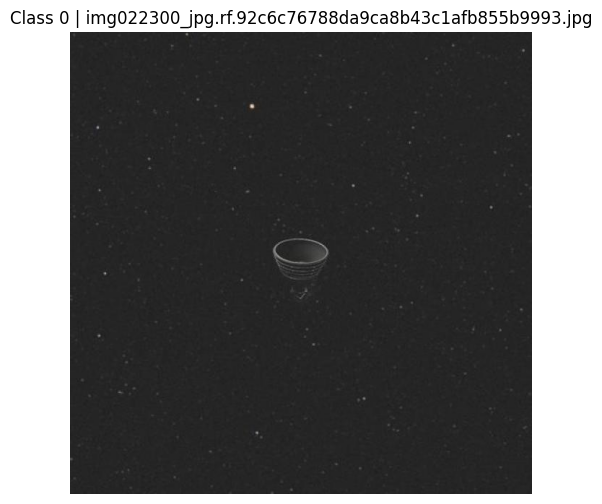

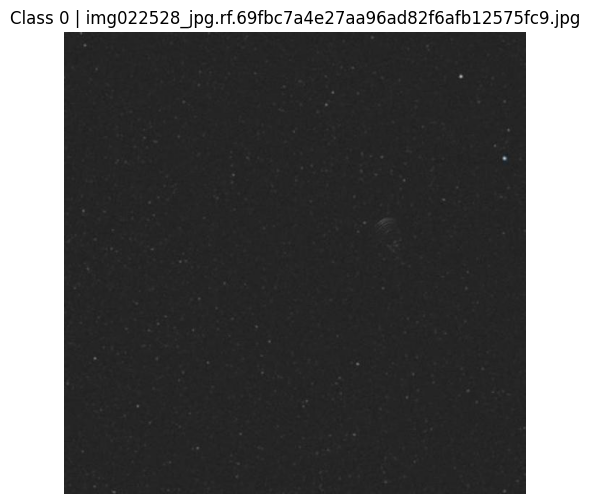

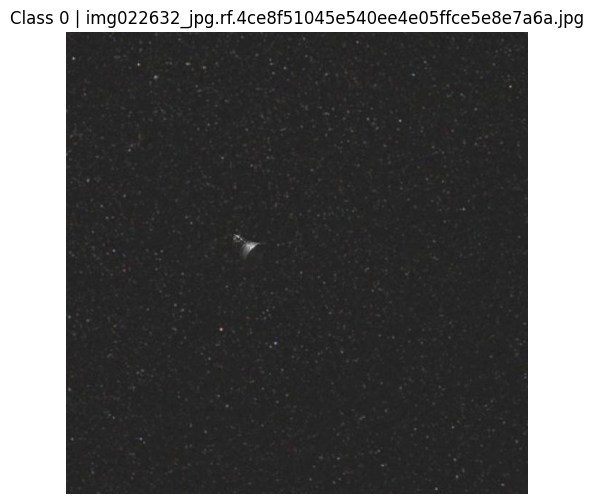

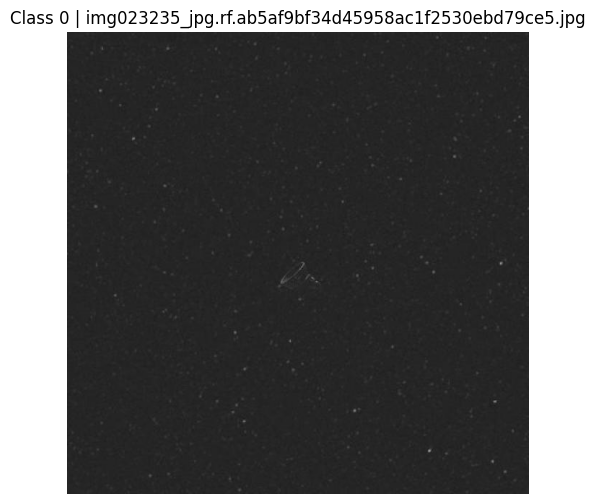

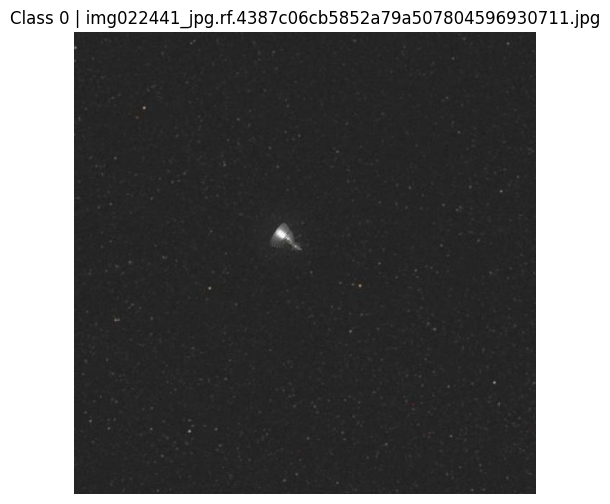

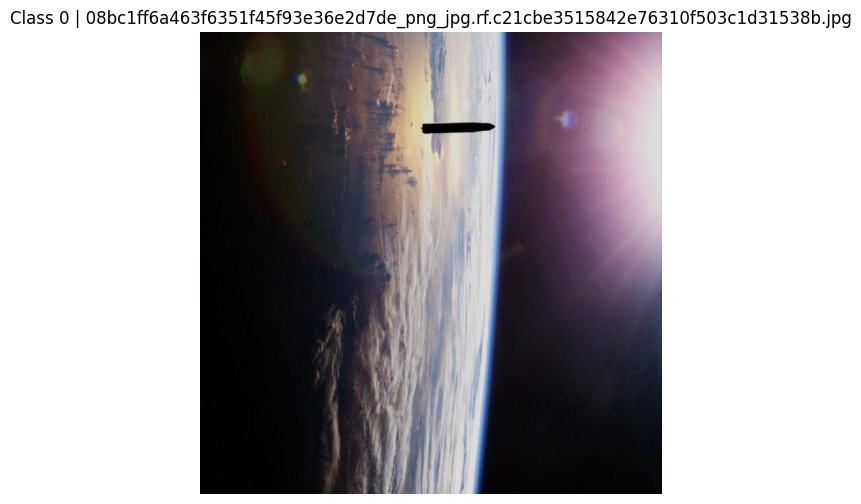

In [ ]:
import os
import glob
import random
import cv2
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Find images containing a particular class
# ---------------------------------------------------------

def find_images_for_class(split, target_class, num_images=6):

    image_dir = os.path.join(
        PROCESSED_DATASET,
        split,
        "images"
    )

    label_dir = os.path.join(
        PROCESSED_DATASET,
        split,
        "labels"
    )

    matching_images = []

    label_files = glob.glob(
        os.path.join(label_dir, "*.txt")
    )

    for label_file in label_files:

        found = False

        with open(label_file, "r") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                class_id = int(line.split()[0])

                if class_id == target_class:
                    found = True
                    break

        if found:

            filename = os.path.splitext(
                os.path.basename(label_file)
            )[0]

            # Find corresponding image
            for ext in [".jpg", ".jpeg", ".png", ".webp"]:

                image_path = os.path.join(
                    image_dir,
                    filename + ext
                )

                if os.path.exists(image_path):
                    matching_images.append(image_path)
                    break

    random.shuffle(matching_images)

    return matching_images[:num_images]


# ---------------------------------------------------------
# Display samples
# ---------------------------------------------------------

def display_class_samples(target_class):

    images = find_images_for_class(
        "train",
        target_class,
        6
    )

    print(
        f"Showing images containing Class {target_class}"
    )

    for image_path in images:

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(8, 6))
        plt.imshow(image)

        plt.title(
            f"Class {target_class} | "
            f"{os.path.basename(image_path)}"
        )

        plt.axis("off")
        plt.show()


display_class_samples(0)

Showing images containing Class 1


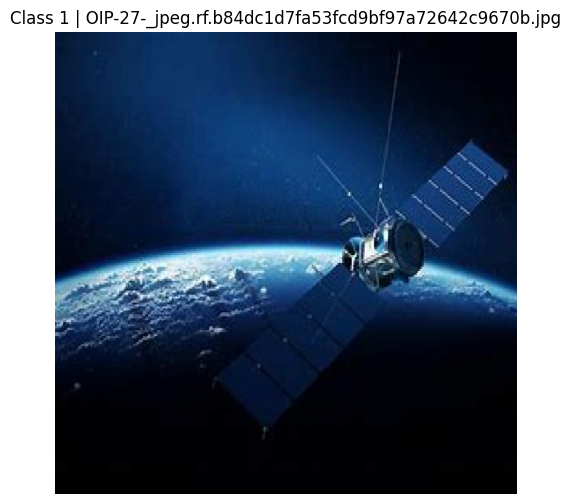

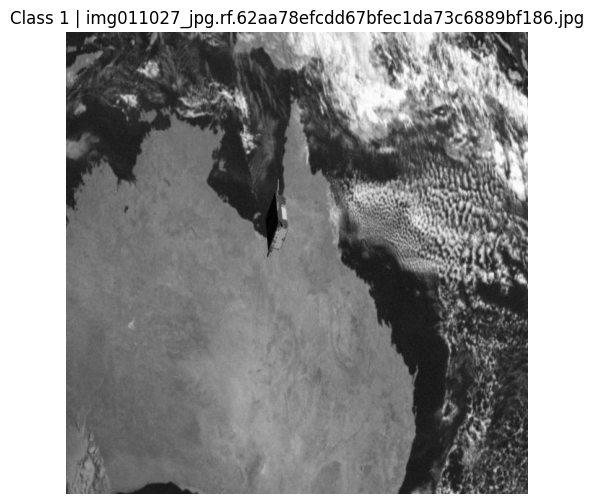

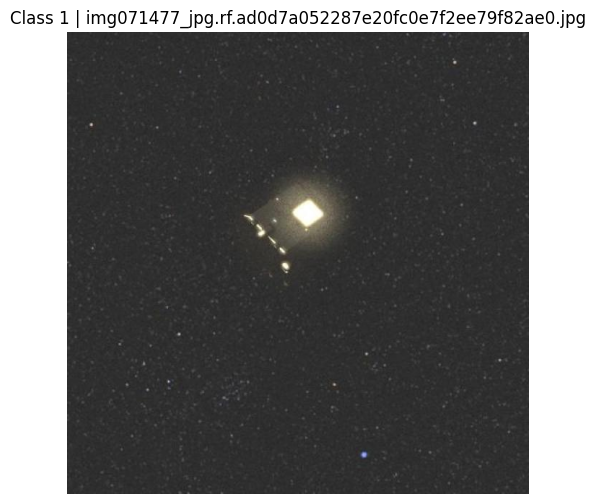

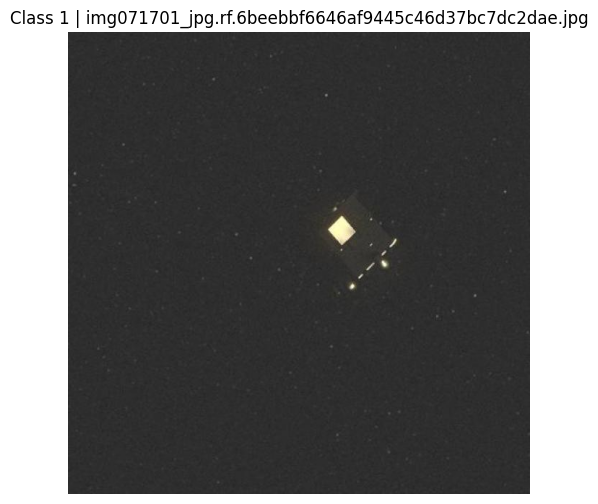

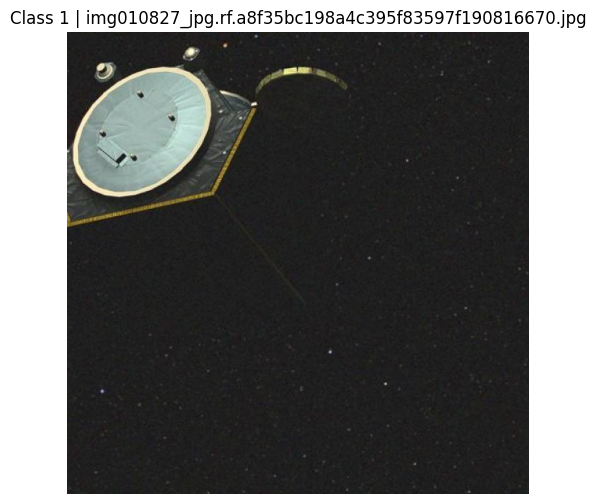

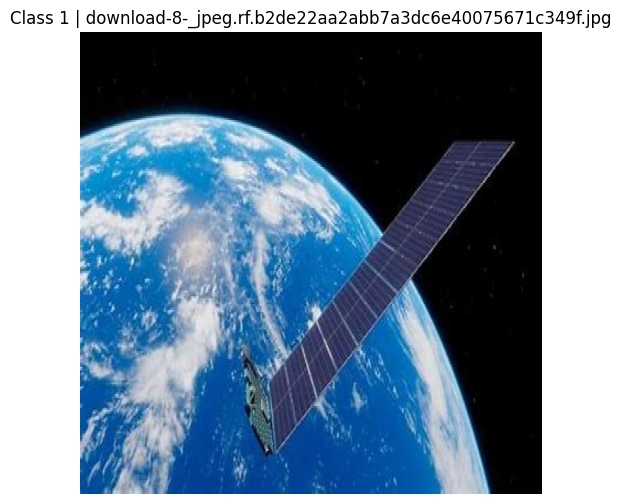

In [ ]:
display_class_samples(1)

In [ ]:
import os

yaml_content = f"""path: {PROCESSED_DATASET}

train: train/images
val: valid/images
test: test/images

names:
  0: Debris
  1: Satellite
"""

yaml_path = os.path.join(
    PROCESSED_DATASET,
    "data.yaml"
)

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created successfully.")
print("\nFile location:")
print(yaml_path)

print("\n========== data.yaml ==========")
print(yaml_content)

data.yaml created successfully.

File location:
/content/Processed_Dataset/data.yaml

========== data.yaml ==========
path: /content/Processed_Dataset

train: train/images
val: valid/images
test: test/images

names:
  0: Debris
  1: Satellite



In [ ]:
with open(yaml_path, "r") as f:
    print(f.read())

path: /content/Processed_Dataset

train: train/images
val: valid/images
test: test/images

names:
  0: Debris
  1: Satellite



In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 4.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

print("Ultralytics imported successfully.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics imported successfully.


In [ ]:
import os

print("YAML path:", yaml_path)
print("\nYAML exists:", os.path.exists(yaml_path))

with open(yaml_path, "r") as f:
    print("\n========== data.yaml ==========")
    print(f.read())

YAML path: /content/Processed_Dataset/data.yaml

YAML exists: True

========== data.yaml ==========
path: /content/Processed_Dataset

train: train/images
val: valid/images
test: test/images

names:
  0: Debris
  1: Satellite



model trainning


In [ ]:
import os

print("YAML path:", yaml_path)
print("YAML exists:", os.path.exists(yaml_path))

with open(yaml_path, "r") as f:
    print("\n========== data.yaml ==========")
    print(f.read())

YAML path: /content/Processed_Dataset/data.yaml
YAML exists: True

========== data.yaml ==========
path: /content/Processed_Dataset

train: train/images
val: valid/images
test: test/images

names:
  0: Debris
  1: Satellite



In [ ]:
results = model.train(
    data=yaml_path,
    epochs=5,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    project="/content/YOLO_Space_Debris",
    name="sanity_check",
    exist_ok=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Processed_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sanity_check, nbs=64, nms=

In [ ]:
import os

best_model = "/content/YOLO_Space_Debris/sanity_check/weights/best.pt"

print("Best model exists:", os.path.exists(best_model))
print("Model path:", best_model)

Best model exists: True
Model path: /content/YOLO_Space_Debris/sanity_check/weights/best.pt


In [ ]:
from ultralytics import YOLO

# Load fresh pretrained YOLO11n
model = YOLO("yolo11n.pt")

# Final training
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=10,
    project="/content/YOLO_Space_Debris",
    name="final_yolo11n",
    exist_ok=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Processed_Dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_yolo11n, nbs=64, nm

In [ ]:
best_model = "/content/YOLO_Space_Debris/final_yolo11n/weights/best.pt"

import os

print("Best model exists:", os.path.exists(best_model))
print("Best model:", best_model)

Best model exists: True
Best model: /content/YOLO_Space_Debris/final_yolo11n/weights/best.pt


In [ ]:
from ultralytics import YOLO

best_model = "/content/YOLO_Space_Debris/final_yolo11n/weights/best.pt"

model = YOLO(best_model)

test_results = model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    project="/content/YOLO_Space_Debris",
    name="test_evaluation",
    exist_ok=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 8.6±7.6 MB/s, size: 40.8 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/Processed_Dataset/test/labels... 355 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 355/355 500.8it/s 0.7s
val: New cache created: /content/Processed_Dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 5.2it/s 4.5s
                   all        355        396       0.86      0.826       0.88      0.593
                Debris         29         74      0.769      0.703      0.779      0.482
             Satellite        321        322       0.95      0.949      0.981      0.705


In [ ]:
from ultralytics import YOLO
import os

best_model = "/content/YOLO_Space_Debris/final_yolo11n/weights/best.pt"

model = YOLO(best_model)

prediction_results = model.predict(
    source="/content/Processed_Dataset/test/images",
    imgsz=640,
    conf=0.25,
    device=0,
    save=True,
    save_conf=True,
    project="/content/YOLO_Space_Debris",
    name="test_predictions",
    exist_ok=True
)

print("Prediction completed.")
print("Results saved to:")
print("/content/YOLO_Space_Debris/test_predictions")


image 1/355 /content/Processed_Dataset/test/images/-10_png_jpg.rf.53fd7a8c2f0eababd67c4937985f0f6b.jpg: 640x640 4 Debriss, 7.9ms
image 2/355 /content/Processed_Dataset/test/images/-11_png_jpg.rf.2f13d374a897f7df71da809b66f3567a.jpg: 640x640 1 Debris, 7.9ms
image 3/355 /content/Processed_Dataset/test/images/-20_png_jpg.rf.919fd2039105f444956953f5bfe77522.jpg: 640x640 1 Debris, 7.7ms
image 4/355 /content/Processed_Dataset/test/images/-22_png_jpg.rf.31f34285e67694d88307d0d45b18e415.jpg: 640x640 3 Debriss, 7.7ms
image 5/355 /content/Processed_Dataset/test/images/-2_png_jpg.rf.8542f03f50d5aaf45ba38ce36972dcb7.jpg: 640x640 1 Debris, 7.7ms
image 6/355 /content/Processed_Dataset/test/images/-30_png_jpg.rf.bb30cca1aec691fa953dba52ac552e28.jpg: 640x640 12 Debriss, 7.9ms
image 7/355 /content/Processed_Dataset/test/images/-33_png_jpg.rf.862a7ccfc837d10c270744e839e61899.jpg: 640x640 10 Debriss, 13.9ms
image 8/355 /content/Processed_Dataset/test/images/-34_png_jpg.rf.7d8154b41ad28c65f381a6cf776a950

Prediction images found: 355


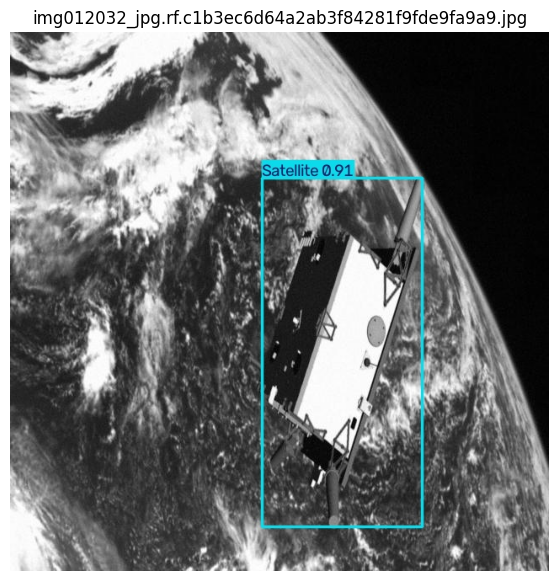

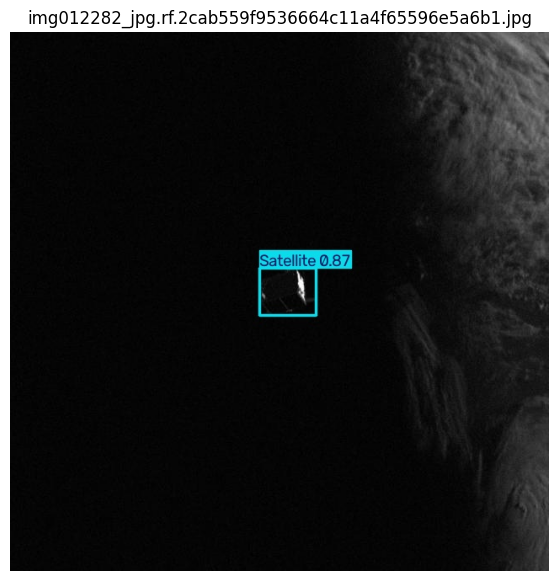

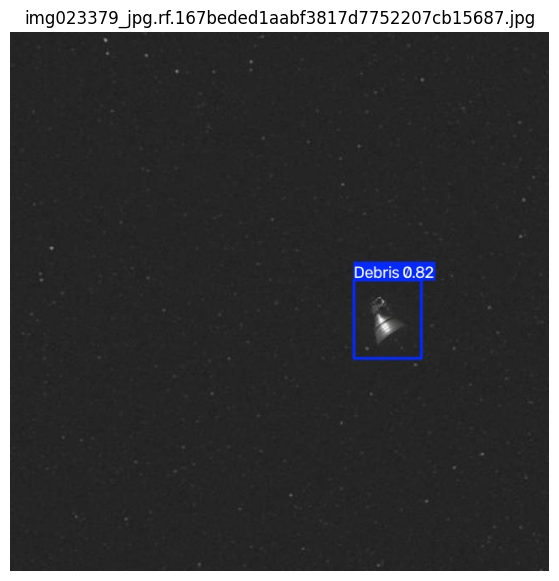

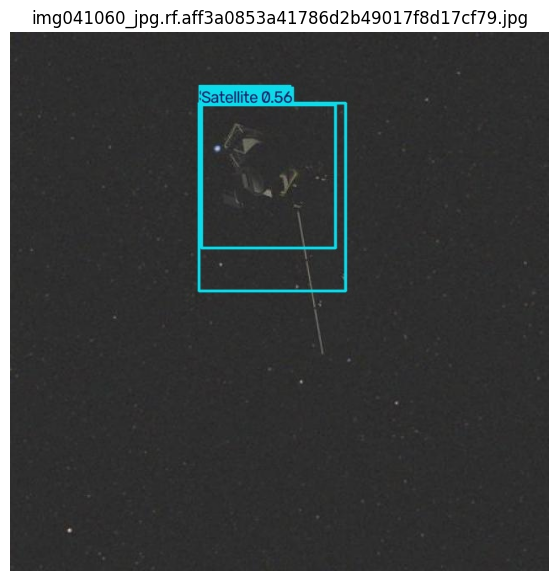

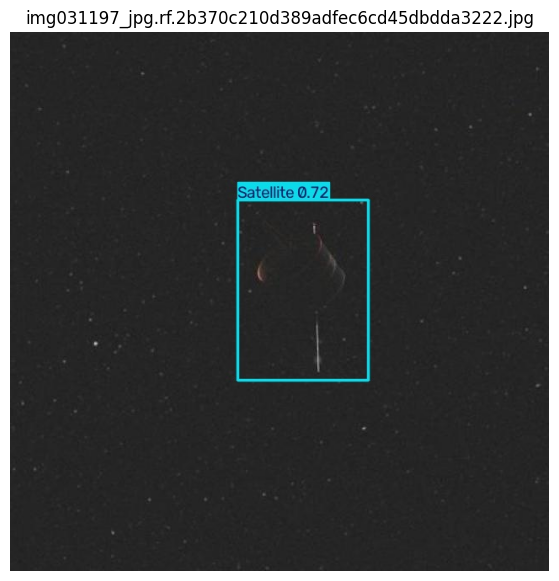

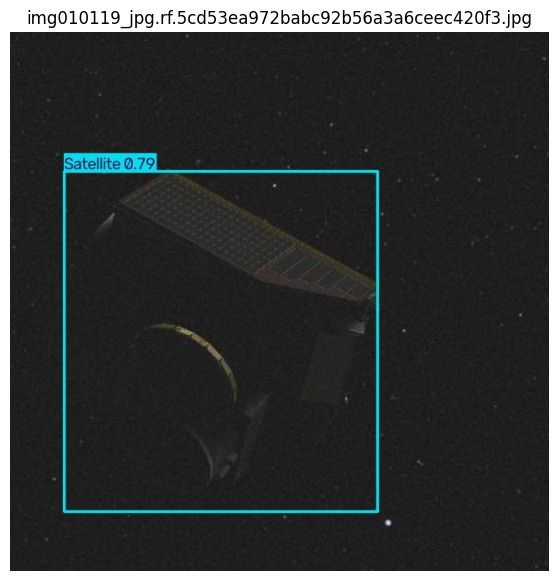

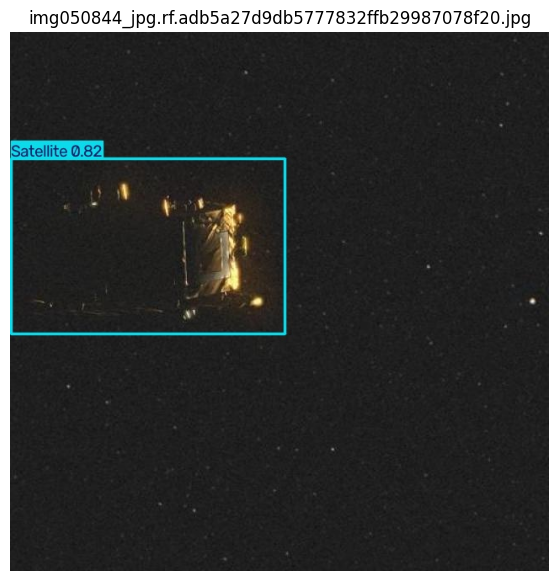

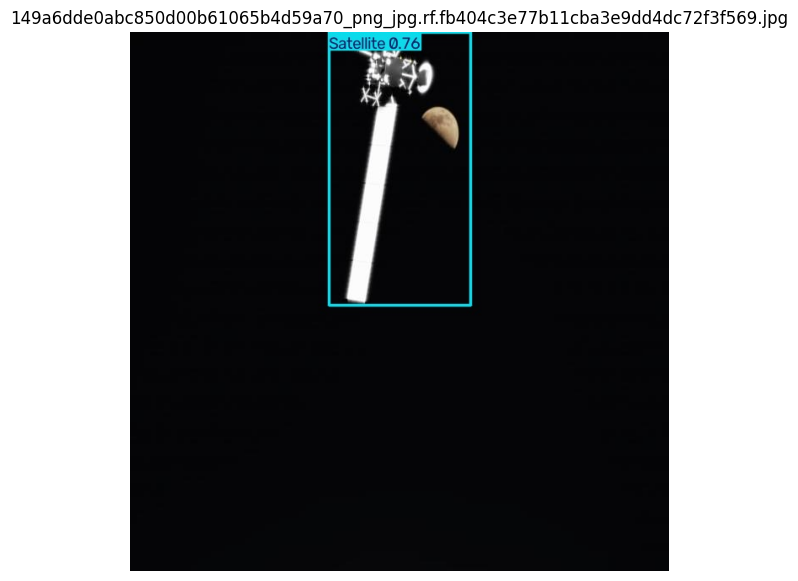

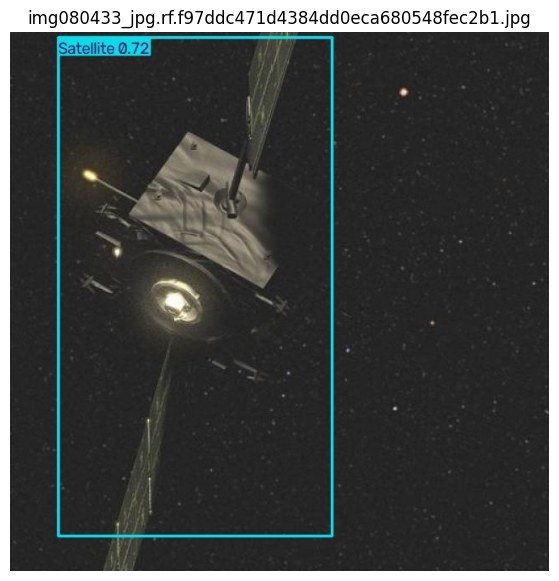

In [ ]:
import os
import glob
import random
from PIL import Image
import matplotlib.pyplot as plt

prediction_dir = "/content/YOLO_Space_Debris/test_predictions"

prediction_images = glob.glob(
    os.path.join(prediction_dir, "*.jpg")
)

print("Prediction images found:", len(prediction_images))

# Select 9 random predictions
sample_images = random.sample(
    prediction_images,
    min(9, len(prediction_images))
)

for image_path in sample_images:

    img = Image.open(image_path)

    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.title(os.path.basename(image_path))
    plt.axis("off")
    plt.show()

In [ ]:
from ultralytics import YOLO

best_model = "/content/YOLO_Space_Debris/final_yolo11n/weights/best.pt"

model = YOLO(best_model)

model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,
    project="/content/YOLO_Space_Debris",
    name="final_test_analysis",
    exist_ok=True
)

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,542 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 794.5±293.0 MB/s, size: 35.4 KB)
val: Scanning /content/Processed_Dataset/test/labels.cache... 355 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 355/355 70.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.0it/s 7.6s
                   all        355        396       0.86      0.826       0.88      0.593
                Debris         29         74      0.769      0.703      0.779      0.482
             Satellite        321        322       0.95      0.949      0.981      0.705
Speed: 4.2ms preprocess, 4.7ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/YOLO_Space_Debris/final_test_analysis


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e3522c84620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
import os

analysis_dir = "/content/YOLO_Space_Debris/final_test_analysis"

print("Files generated:")
for file in sorted(os.listdir(analysis_dir)):
    print(file)

Files generated:
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg


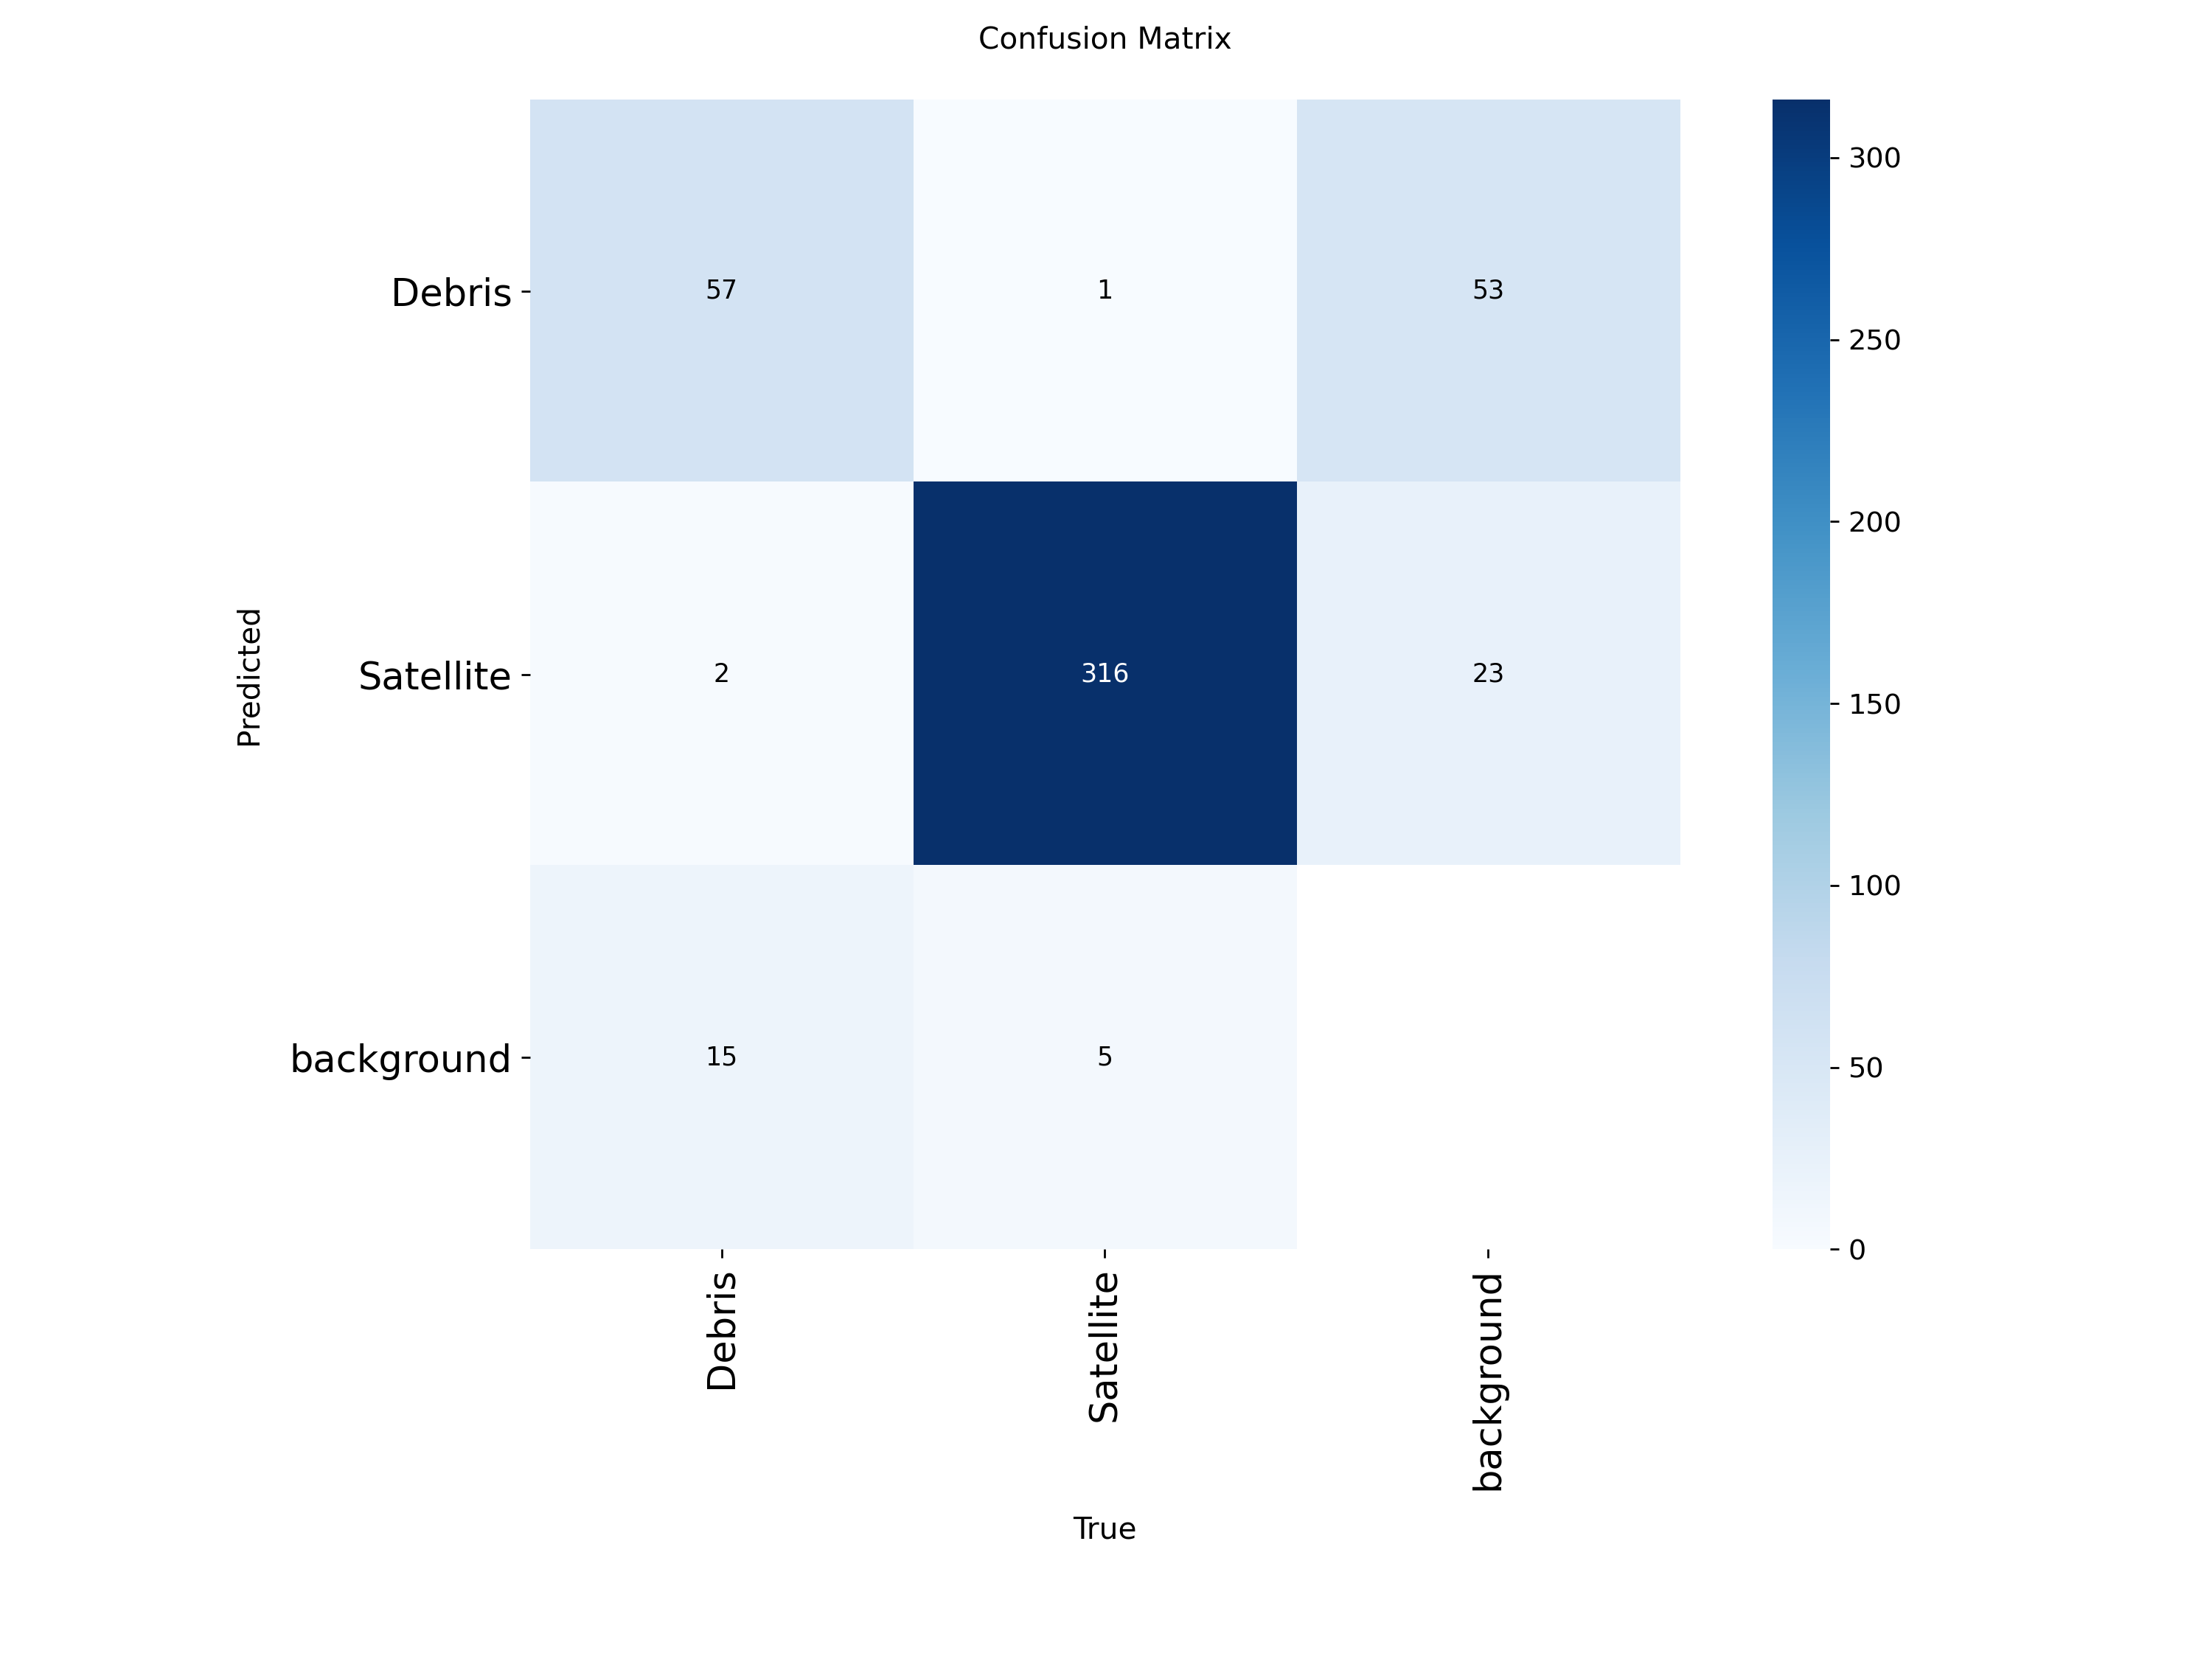

In [ ]:
from IPython.display import display
from PIL import Image

cm_path = "/content/YOLO_Space_Debris/final_test_analysis/confusion_matrix.png"

display(Image.open(cm_path))

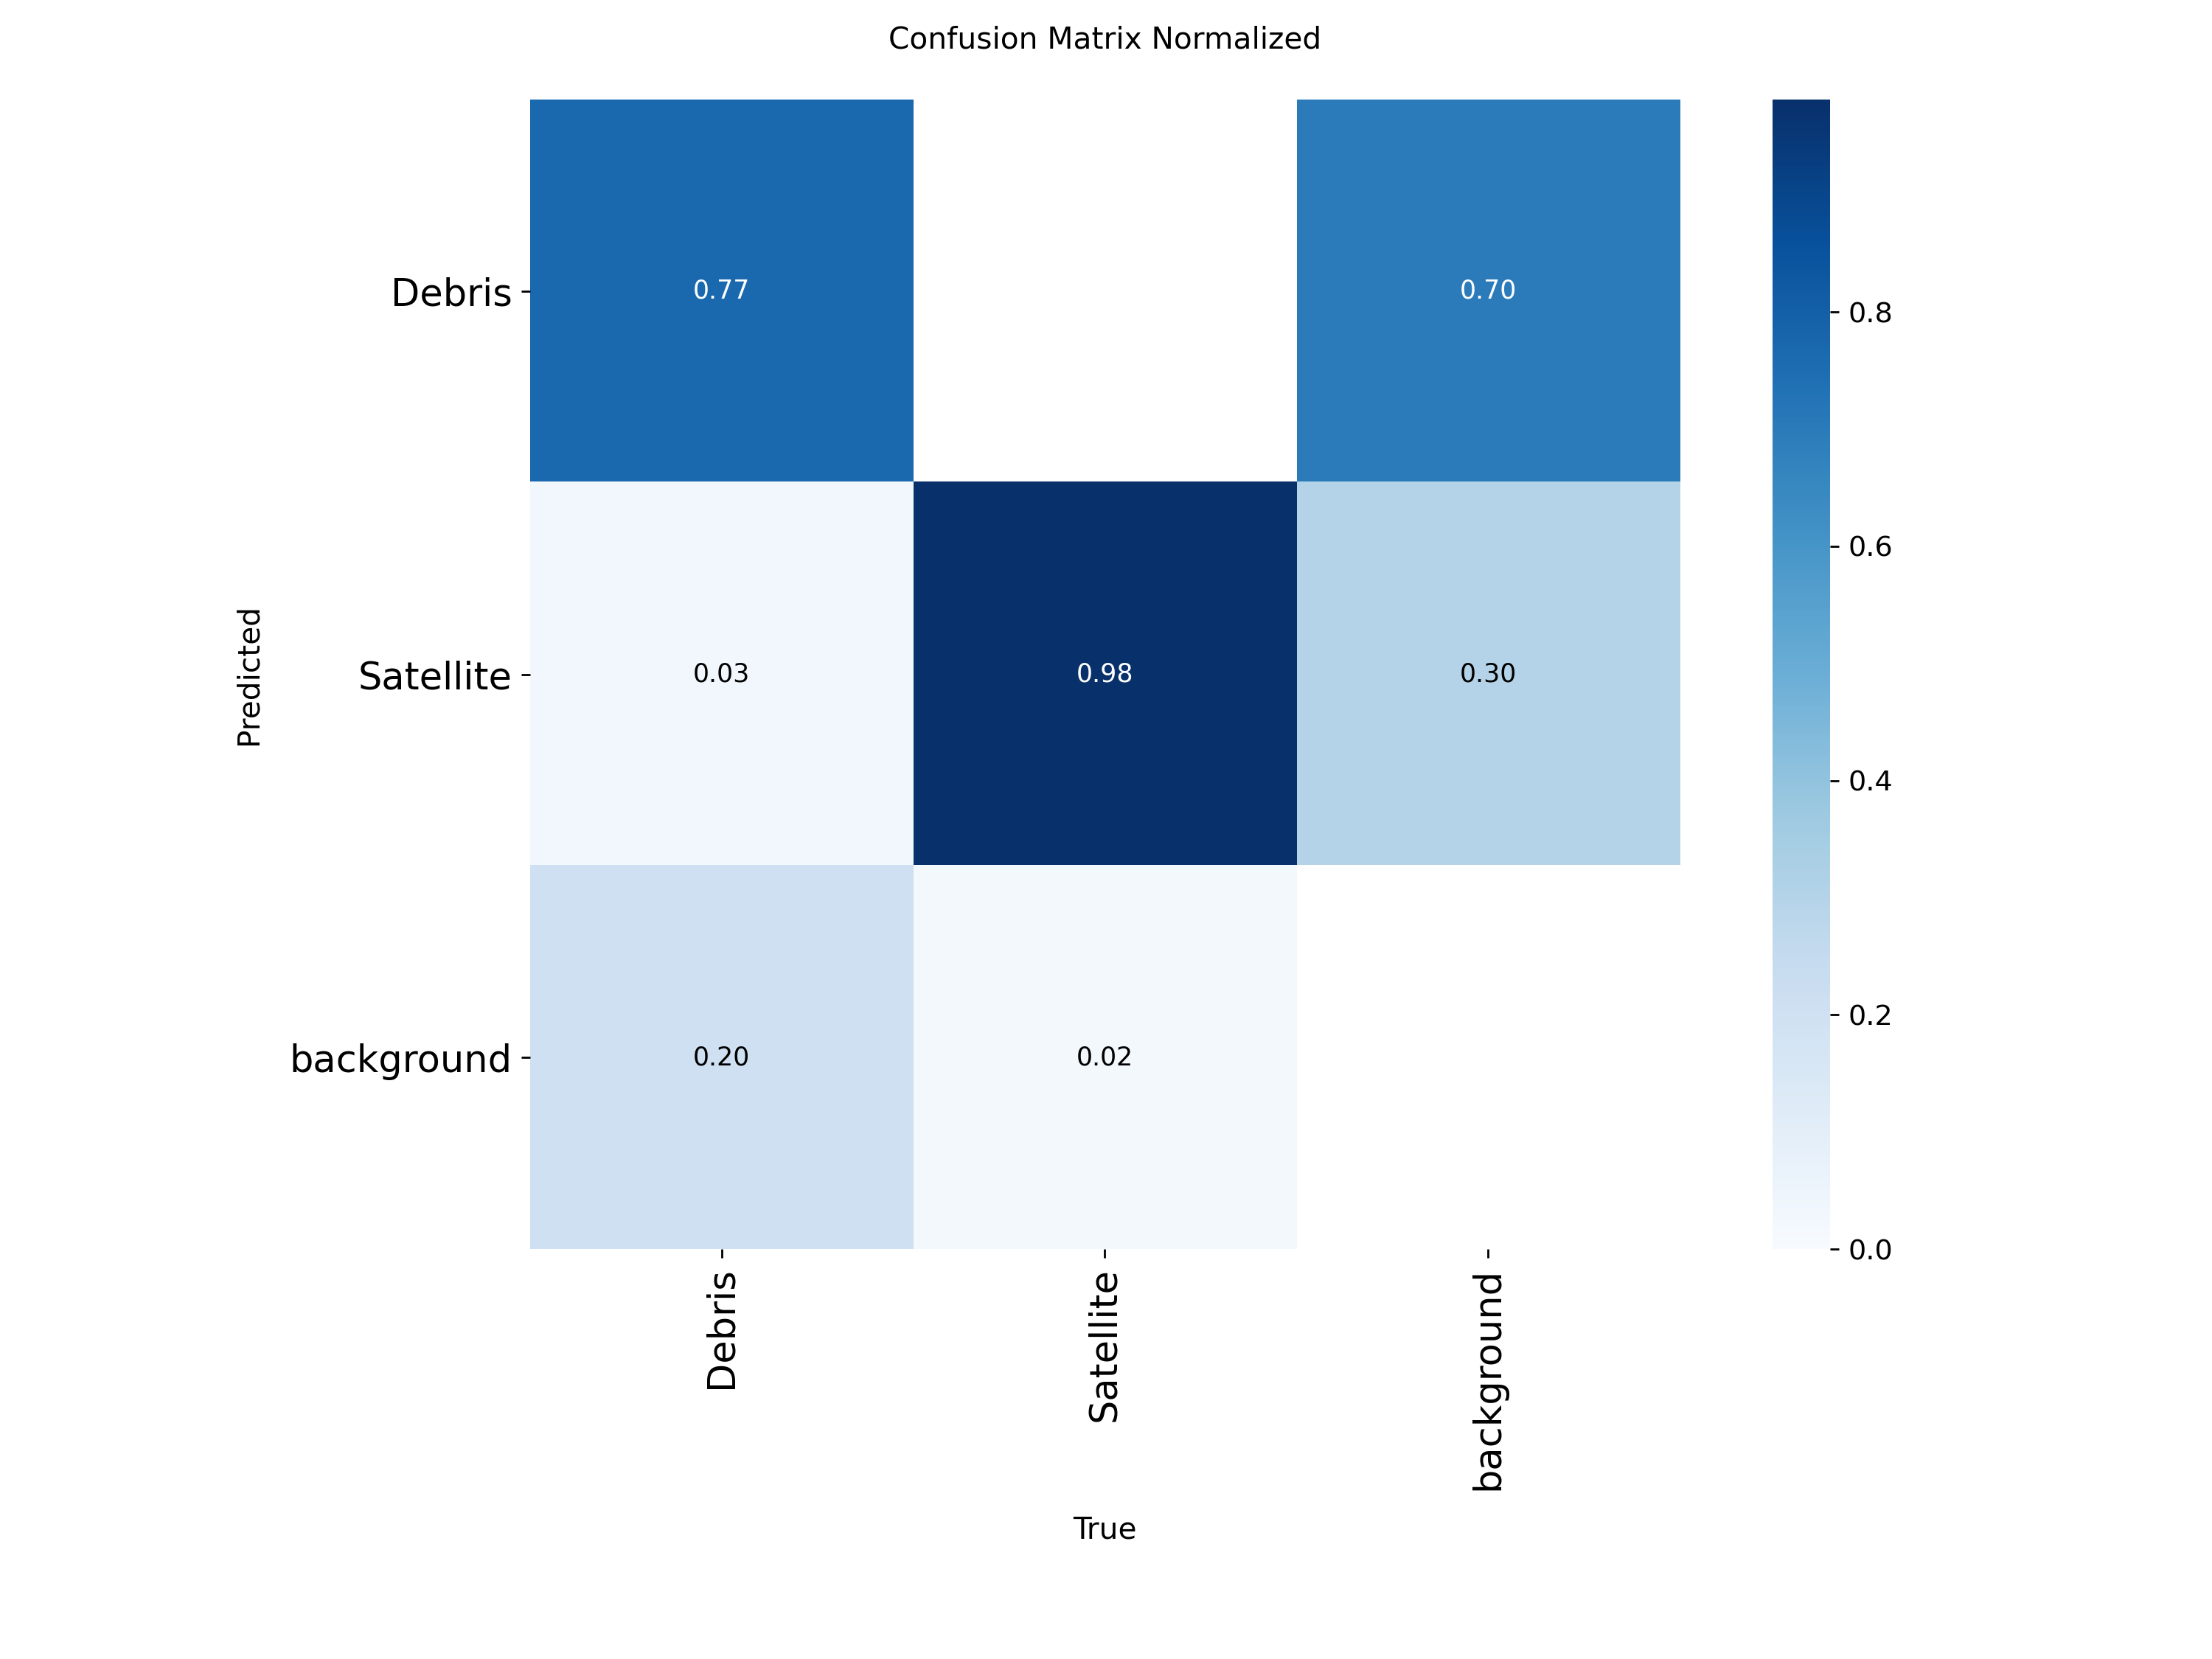

In [ ]:
##normalized version

cm_norm_path = "/content/YOLO_Space_Debris/final_test_analysis/confusion_matrix_normalized.png"

display(Image.open(cm_norm_path))

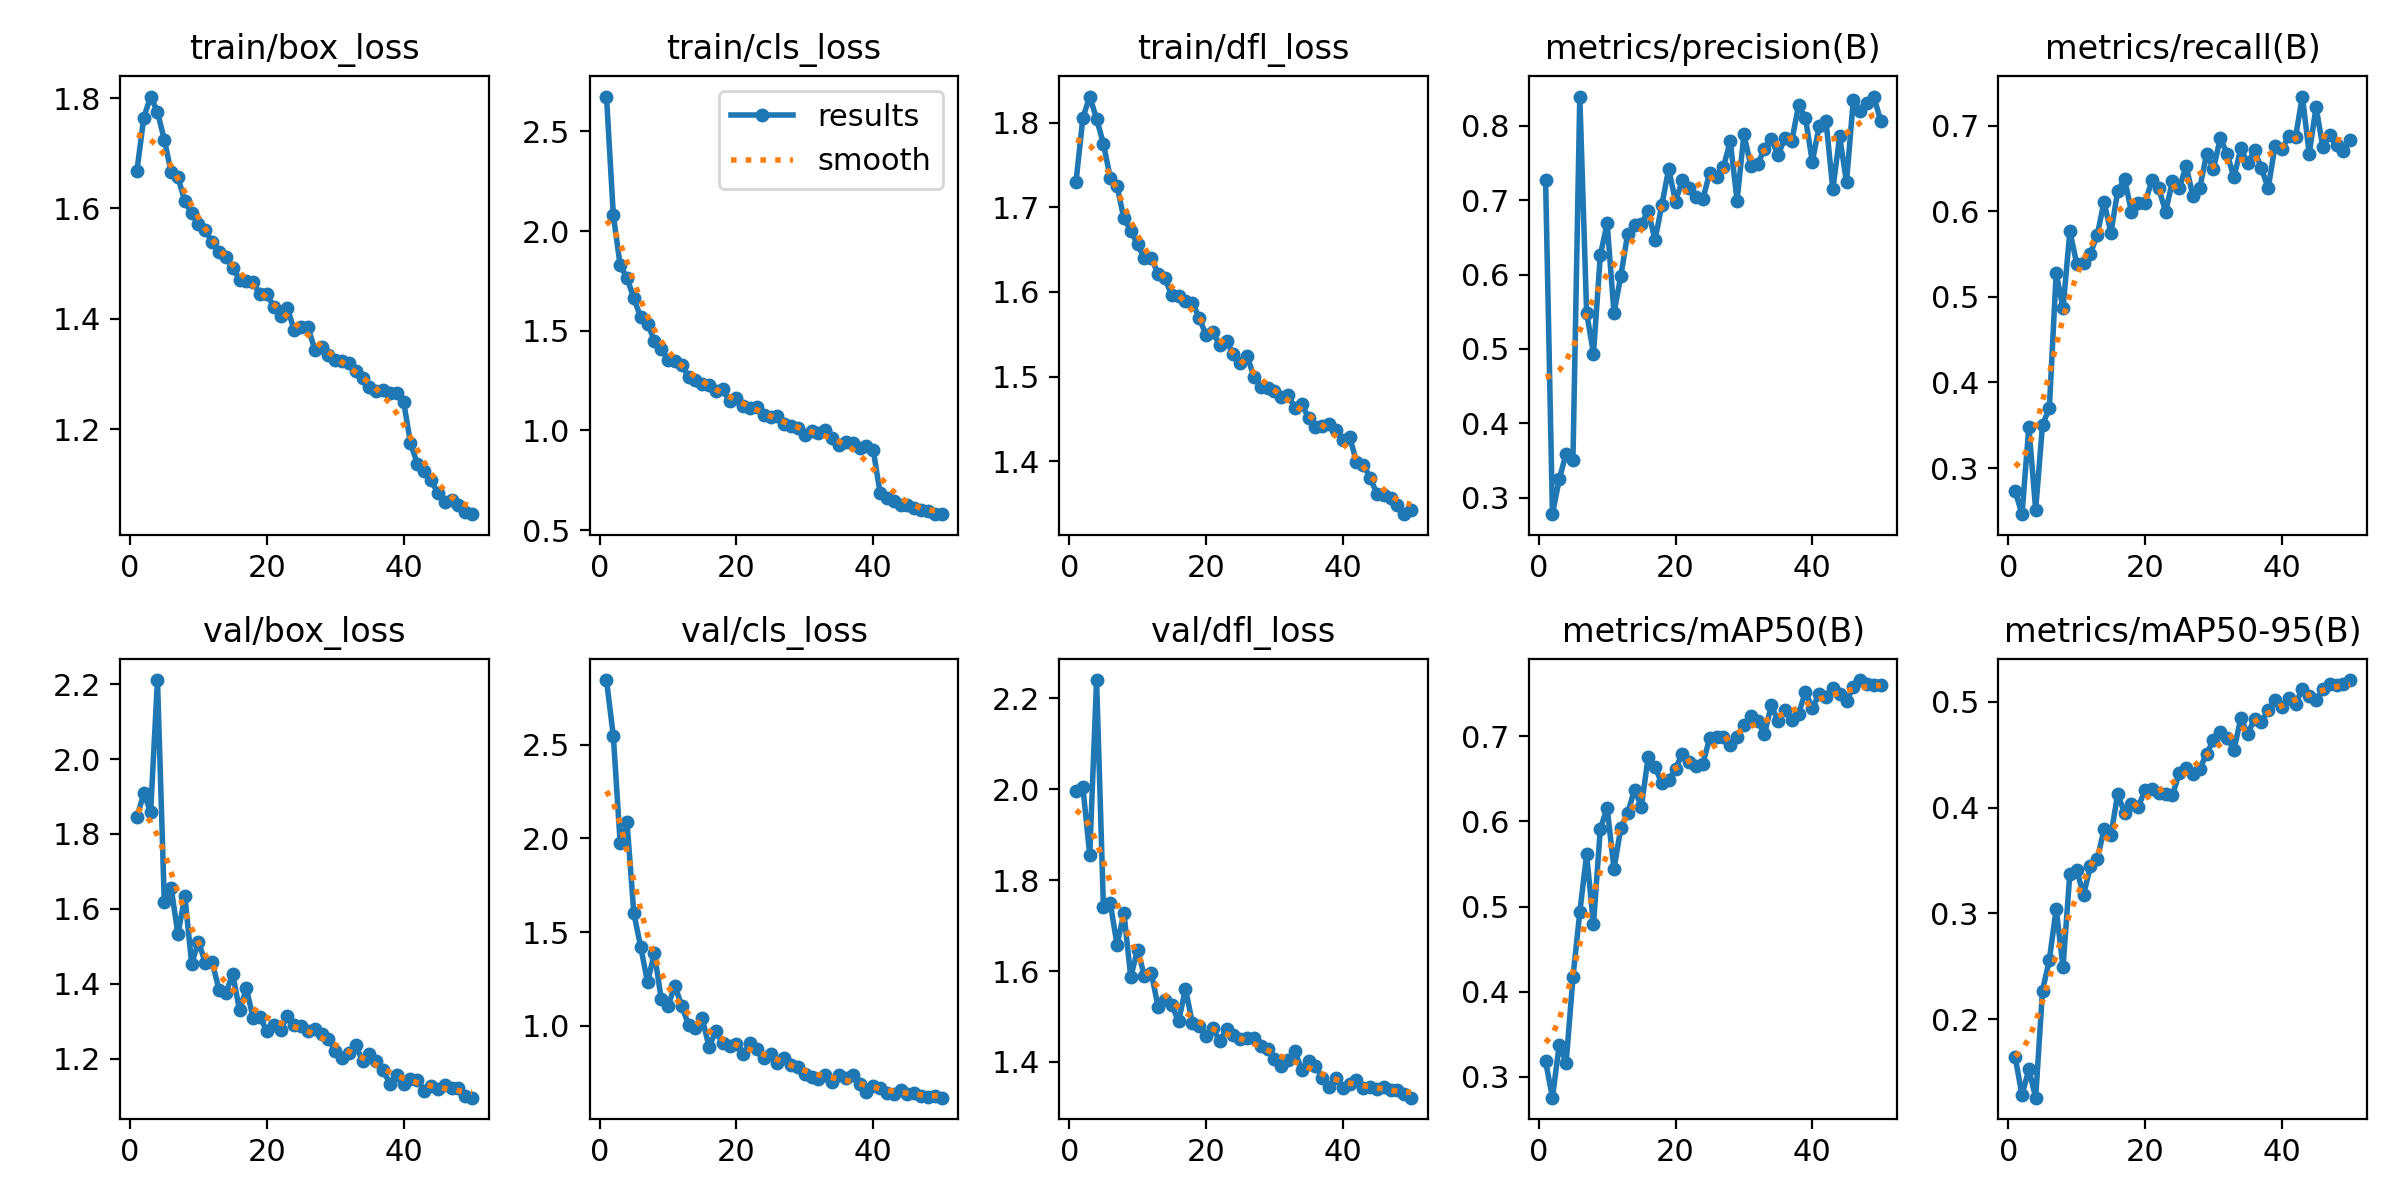

In [ ]:
results_path = "/content/YOLO_Space_Debris/final_yolo11n/results.png"

display(Image.open(results_path))

In [ ]:
import os

analysis_dir = "/content/YOLO_Space_Debris/final_test_analysis"

if os.path.exists(analysis_dir):
    print("Files in final_test_analysis:")
    for root, dirs, files in os.walk(analysis_dir):
        for file in files:
            print(os.path.join(root, file))
else:
    print("Directory does not exist:")
    print(analysis_dir)

Files in final_test_analysis:
/content/YOLO_Space_Debris/final_test_analysis/BoxF1_curve.png
/content/YOLO_Space_Debris/final_test_analysis/val_batch0_pred.jpg
/content/YOLO_Space_Debris/final_test_analysis/BoxR_curve.png
/content/YOLO_Space_Debris/final_test_analysis/confusion_matrix_normalized.png
/content/YOLO_Space_Debris/final_test_analysis/val_batch2_pred.jpg
/content/YOLO_Space_Debris/final_test_analysis/BoxP_curve.png
/content/YOLO_Space_Debris/final_test_analysis/val_batch0_labels.jpg
/content/YOLO_Space_Debris/final_test_analysis/val_batch1_pred.jpg
/content/YOLO_Space_Debris/final_test_analysis/confusion_matrix.png
/content/YOLO_Space_Debris/final_test_analysis/val_batch2_labels.jpg
/content/YOLO_Space_Debris/final_test_analysis/BoxPR_curve.png
/content/YOLO_Space_Debris/final_test_analysis/val_batch1_labels.jpg


In [ ]:
import os

base_dir = "/content/YOLO_Space_Debris"

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith((".png", ".jpg", ".csv")):
            print(os.path.join(root, file))

/content/YOLO_Space_Debris/final_yolo11n/BoxF1_curve.png
/content/YOLO_Space_Debris/final_yolo11n/train_batch2.jpg
/content/YOLO_Space_Debris/final_yolo11n/val_batch0_pred.jpg
/content/YOLO_Space_Debris/final_yolo11n/BoxR_curve.png
/content/YOLO_Space_Debris/final_yolo11n/results.csv
/content/YOLO_Space_Debris/final_yolo11n/results.png
/content/YOLO_Space_Debris/final_yolo11n/confusion_matrix_normalized.png
/content/YOLO_Space_Debris/final_yolo11n/val_batch2_pred.jpg
/content/YOLO_Space_Debris/final_yolo11n/train_batch1.jpg
/content/YOLO_Space_Debris/final_yolo11n/train_batch9322.jpg
/content/YOLO_Space_Debris/final_yolo11n/BoxP_curve.png
/content/YOLO_Space_Debris/final_yolo11n/train_batch9321.jpg
/content/YOLO_Space_Debris/final_yolo11n/val_batch0_labels.jpg
/content/YOLO_Space_Debris/final_yolo11n/val_batch1_pred.jpg
/content/YOLO_Space_Debris/final_yolo11n/confusion_matrix.png
/content/YOLO_Space_Debris/final_yolo11n/val_batch2_labels.jpg
/content/YOLO_Space_Debris/final_yolo11n/tr

In [ ]:
import os

project_dir = "/content/YOLO_Space_Debris"

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        print(f"{indent}  {file}")

YOLO_Space_Debris/
  final_yolo11n/
    BoxF1_curve.png
    train_batch2.jpg
    val_batch0_pred.jpg
    BoxR_curve.png
    results.csv
    results.png
    confusion_matrix_normalized.png
    val_batch2_pred.jpg
    train_batch1.jpg
    train_batch9322.jpg
    BoxP_curve.png
    train_batch9321.jpg
    val_batch0_labels.jpg
    val_batch1_pred.jpg
    confusion_matrix.png
    val_batch2_labels.jpg
    train_batch9320.jpg
    BoxPR_curve.png
    val_batch1_labels.jpg
    train_batch0.jpg
    labels.jpg
    args.yaml
    weights/
      best.pt
      last.pt
  test_predictions/
    0e20a6e4efcaef1b0b36764c204f440e_png_jpg.rf.51debedafa0d2496b6dc739e8ed2a747.jpg
    img100903_jpg.rf.843bdaa912505da01a6cc72301eaa734.jpg
    410b42cfd63c7a3273605f1cf0ff43be_png_jpg.rf.0480e79ef4f3bf343a6f483e0d5b7cc3.jpg
    11126ab9cb18bcd2d7f455d688aeace3_png_jpg.rf.5294161e45174db4311316a96bd0000d.jpg
    img008944_jpg.rf.22d4086413827e42577384b248aceb3c.jpg
    18aff9e5291bdb72aaa78057be1f900e_png_jpg.rf

In [ ]:
import shutil

project_dir = "/content/YOLO_Space_Debris"
zip_path = "/content/YOLO_Space_Debris_final"

shutil.make_archive(
    zip_path,
    'zip',
    project_dir
)

print("Saved:", zip_path + ".zip")

Saved: /content/YOLO_Space_Debris_final.zip


In [ ]:
from google.colab import files

files.download("/content/YOLO_Space_Debris_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

training/validation performance graph